In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import seaborn as sns
import scipy
from scipy import stats
import os
import pickle

In [5]:
data_labels = []
# path = '/mnt/d/Documents_D/Rojas_lab/data' # the base directory path
path = '/Users/felixbarber/d/Documents_D/Rojas_lab/data' # the base directory path
path='/Volumes/data_ssd1/Rojas_Lab/data' 
num_rep=4 # this is the number of repeats of each condition.
# expt_id = '/240702_Tun_sensitivity' # the experiment title
# expt_id = '/240723_bFB66_Tun_sensitivity' # the experiment title
expt_id = '/231208_Tuni_growth_curves' # the experiment title


In [6]:
temp_path = './outputs'+expt_id+expt_id+'_growth_rate_df.pkl'
with open(temp_path, 'rb') as input:
    df_gr=pickle.load(input)
temp_path = './outputs'+expt_id+expt_id+'_sat_OD_df.pkl'
with open(temp_path, 'rb') as input:
    df_OD=pickle.load(input)
    
to_plot=[]
with open(path+expt_id+expt_id+'_curated.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for temp_row in csv_reader:
        to_plot.append(temp_row[0])
        line_count += 1
celltypes=[['Blank','WT','tagO'], ['', r'$WT$',r'$\Delta tagO$']]

In [ ]:
num_rep1=4 # this is the number of repeats of each condition.

path1='/Volumes/data_ssd1/Rojas_Lab/data' 
# expt_id1 = '/221105_PonA_TPase_Tun_sensitivity' # the experiment title
# celltypes1=[['Blank','bFB149','bFB145', 'bFB69'], ['', r'$WT$',r'$ponA_{TP-}$', r'$\Delta ponA$']]
# path1='/Volumes/data_ssd2/Rojas_Lab/data' 
# expt_id1 = '/240724_ponA_Tun_sensitivity' # the experiment title
# celltypes1=[['Blank','bFB66','bFB145', 'bFB69'], ['', r'$WT$',r'$ponA_{TP-}$', r'$\Delta ponA$']]
path1='/Volumes/data_ssd2/Rojas_Lab/data' 
expt_id1 = '/240725_ponA_Tun_sensitivity' # the experiment title
celltypes1=[['Blank','bFB66','bFB145', 'bFB69'], ['', r'$WT$',r'$ponA_{TP-}$', r'$\Delta ponA$']]

In [7]:
df=df_gr.copy()
df['Maximum OD'] = df_OD['Max. density']
temp=[]
for i0 in range(len(df)):
    if df['Condition'].iloc[i0]=='Blank':
        temp.append(i0)
df=df.reset_index(drop=True)
df=df.drop(temp)
df.head(10)
df=df.reset_index(drop=True)
temp1, temp2 = [], []        
for i0 in range(len(df)):    
    ind=np.nonzero([it in df['Condition'].iloc[i0] for it in celltypes[0]])[0][0]
    temp1.append(celltypes[1][ind])
    temp2.append(df['Condition'].iloc[i0][len(celltypes[0][ind])+1:])
df['Celltype'] = temp1
df['Growth condition'] = temp2

In [8]:
tun_conc=[0.0,0.12, 0.25, 0.5, 1,2,4,8,16,24,32]
tun_concs=[]
for ind in range(len(df)):
    tun_concs.append(tun_conc['Tunicamycin' in df['Growth condition'][ind]])
df['Tunicamycin conc']=tun_concs

In [9]:
temp=df['Growth condition'].unique()
sel_conds=[0,1]
temp_ord=[temp[ind] for ind in sel_conds]
temp_hue = [r'$WT$',r'$\Delta tagO$']

In [10]:
df['Growth condition'].unique()

array(['0.125ug/mL Tunicamycin', '0.25ug/mL Tunicamycin',
       '0.5ug/mL Tunicamycin', '16ug/mL Tunicamycin',
       '1ug/mL Tunicamycin', '24ug/mL Tunicamycin', '2ug/mL Tunicamycin',
       '32ug/mL Tunicamycin', '4ug/mL Tunicamycin', '8ug/mL Tunicamycin',
       'LB', ''], dtype=object)

In [11]:
df['Celltype'].unique()

array(['$WT$', '$\\Delta tagO$'], dtype=object)

In [12]:
for celltype in df.Celltype.unique():
    print(celltype, df[df.Celltype==celltype]['Growth condition'].unique())

$WT$ ['0.125ug/mL Tunicamycin' '0.25ug/mL Tunicamycin' '0.5ug/mL Tunicamycin'
 '16ug/mL Tunicamycin' '1ug/mL Tunicamycin' '24ug/mL Tunicamycin'
 '2ug/mL Tunicamycin' '32ug/mL Tunicamycin' '4ug/mL Tunicamycin'
 '8ug/mL Tunicamycin' 'LB']
$\Delta tagO$ ['']


In [24]:
cond_order=['WT LB',  'WT 0.125ug/mL Tunicamycin', 'WT 0.25ug/mL Tunicamycin',
       'WT 0.5ug/mL Tunicamycin','WT 1ug/mL Tunicamycin', 'WT 2ug/mL Tunicamycin', 
        'WT 4ug/mL Tunicamycin', 'WT 8ug/mL Tunicamycin', 'WT 16ug/mL Tunicamycin',
       'WT 24ug/mL Tunicamycin', 'WT 32ug/mL Tunicamycin','tagO']

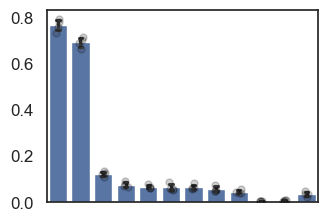

<Figure size 640x480 with 0 Axes>

In [35]:
fig=plt.figure(figsize=[3.5,2.5])
sns.set(font_scale=1.1)
sns.set_style('white')
colors=sns.color_palette()
pal=[colors[0],colors[2],colors[3],colors[1],colors[4]]
sns.barplot(data=df,x='Condition',y='Maximum OD',order=cond_order,capsize=0.15,errorbar='ci')
sns.stripplot(x='Condition',y='Maximum OD',order=cond_order,dodge=True,data=df,color='k',edgecolor='black',linewidth=1,alpha=0.2,legend=False)
# sns.stripplot(data=df,x='Tunicamycin conc',y='Maximum OD',hue='Celltype', hue_order=temp_hue,palette=pal)
ax=plt.gca()
# handles, labels = ax.get_legend_handles_labels()

# plt.legend(loc=[1.01,0.1])
plt.ylabel('')
plt.xlabel('')
xtick_locs,vals=plt.xticks()
ax.set_xticks([])
# plt.xticks(rotation = 50)
# plt.xticks(ticks=xtick_locs,labels=[0.0, 0.5])

fig.savefig('./outputs'+expt_id+expt_id+'_OD_plot_paper_compiled.pdf',bbox_inches='tight')
plt.show()
plt.clf()

One-way anova test for means

In [36]:
outs_anova=[]
print(cond_order)
samples=[np.asarray(df[(df['Condition']==cond)]['Maximum OD']) for cond in cond_order]
outs_anova.append(scipy.stats.f_oneway(*samples, axis=0))
print(cond,outs_anova[-1])
if outs_anova[-1][1]<0.01:
    print('Tukey:', scipy.stats.tukey_hsd(*samples))
    

['WT LB', 'WT 0.125ug/mL Tunicamycin', 'WT 0.25ug/mL Tunicamycin', 'WT 0.5ug/mL Tunicamycin', 'WT 1ug/mL Tunicamycin', 'WT 2ug/mL Tunicamycin', 'WT 4ug/mL Tunicamycin', 'WT 8ug/mL Tunicamycin', 'WT 16ug/mL Tunicamycin', 'WT 24ug/mL Tunicamycin', 'WT 32ug/mL Tunicamycin', 'tagO']
tagO F_onewayResult(statistic=1490.2779098005576, pvalue=2.1499531060480932e-44)
Tukey: Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.073     0.000     0.039     0.107
 (0 - 2)      0.644     0.000     0.610     0.678
 (0 - 3)      0.690     0.000     0.656     0.723
 (0 - 4)      0.699     0.000     0.666     0.733
 (0 - 5)      0.702     0.000     0.668     0.736
 (0 - 6)      0.700     0.000     0.666     0.734
 (0 - 7)      0.709     0.000     0.675     0.743
 (0 - 8)      0.720     0.000     0.686     0.754
 (0 - 9)      0.762     0.000     0.728     0.796
 (0 - 10)      0.759     0.000     0.725     0.793
 (0 - 11)    